---

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import trim_mean
import matplotlib.pyplot as plt
import seaborn as sns
import statistics

# Load the medal dataset
medal_df = pd.read_excel('Medals.xlsx')
medal_df = medal_df.rename(columns={'Team/NOC': 'Country'})
medal_df.head()

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Rank,Team/NOC,Gold,Silver,Bronze,Total,Rank by Total
0,1,United States of America,39,41,33,113,1
1,2,People's Republic of China,38,32,18,88,2
2,3,Japan,27,14,17,58,5
3,4,Great Britain,22,21,22,65,4
4,5,ROC,20,28,23,71,3


In [ ]:
# Summary statistics for medal counts
print('Total medals mean:', medal_df['Total'].mean())
print('Total medals median:', medal_df['Total'].median())
print('Gold medals trimmed mean (10%):', trim_mean(medal_df['Gold'], 0.1))
print('Gold medals weighted mean (Gold weighted by Total):', np.average(medal_df['Gold'], weights=medal_df['Total']))
print('Gold medals variance:', statistics.variance(medal_df['Gold']))
print('Gold medals standard deviation:', statistics.stdev(medal_df['Gold']))
print('Gold medals IQR:', np.percentile(medal_df['Gold'], 75) - np.percentile(medal_df['Gold'], 25))
print('Most frequent gold medal count (mode):', medal_df['Gold'].mode().iat[0])

Mean: 11.612903225806452
Median: 4.0
Trimmed Mean (Gold): 1.96
Weighted Mean (Gold): 14.743518518518519


In [ ]:
# Additional exploratory statistics and derived ratios
summary_stats = medal_df[['Gold', 'Silver', 'Bronze', 'Total']].describe()
display(summary_stats)

medal_df['GoldRatio'] = medal_df['Gold'] / medal_df['Total']
medal_df['SilverRatio'] = medal_df['Silver'] / medal_df['Total']
medal_df['BronzeRatio'] = medal_df['Bronze'] / medal_df['Total']

medal_df[['Country', 'GoldRatio', 'SilverRatio', 'BronzeRatio']].head()

Variance (Gold): 49.315100514259
Standard Deviation (Gold): 7.022471111671375
IQR (Gold): 3.0


,Rank,Gold,Silver,Bronze,Total,Rank by Total
count,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000
mean,46.333333,3.655914,3.634409,4.322581,11.612903,43.494624
std,26.219116,7.022471,6.626339,6.210372,19.091332,24.171769
min,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,24.000000,0.000000,0.000000,1.000000,2.000000,23.000000
50%,46.000000,1.000000,1.000000,2.000000,4.000000,47.000000
75%,70.000000,3.000000,4.000000,5.000000,11.000000,66.000000
max,86.000000,39.000000,41.000000,33.000000,113.000000,77.000000


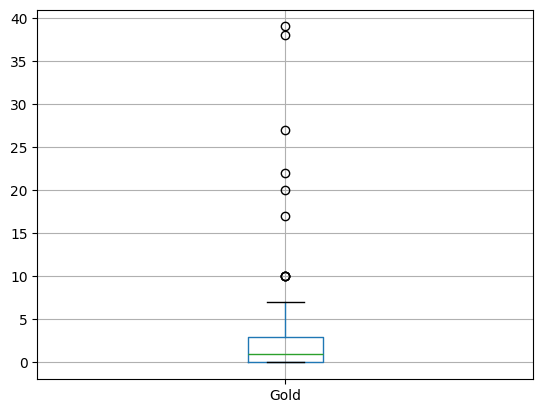

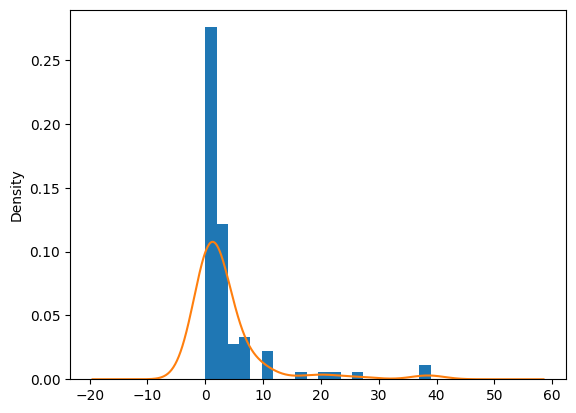

In [ ]:
# Distribution plots for Gold medals
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x=medal_df['Gold'], ax=axes[0], color='skyblue')
axes[0].set_title('Gold Medal Boxplot')
axes[0].set_xlabel('Gold Medals')

sns.histplot(medal_df['Gold'], kde=True, bins=18, ax=axes[1], color='salmon')
axes[1].set_title('Gold Medal Histogram with KDE')
axes[1].set_xlabel('Gold Medals')

plt.tight_layout()
plt.show()

Mode (Gold): 0


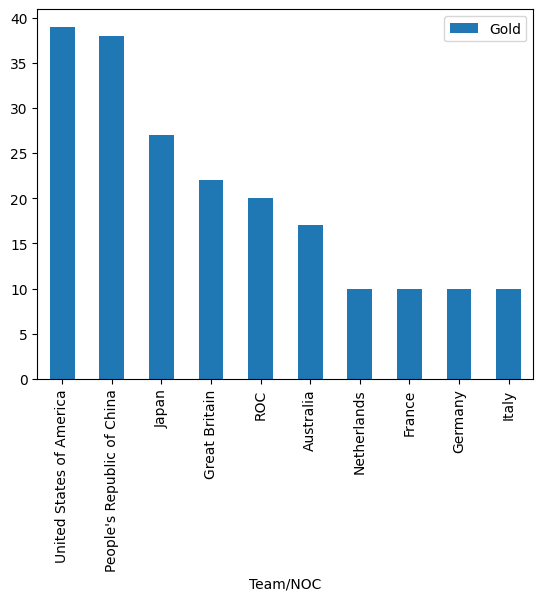

In [ ]:
# Bar chart for the top 10 countries by Gold medals
top_by_gold = medal_df.sort_values('Gold', ascending=False).head(10)

plt.figure(figsize=(11, 5))
sns.barplot(data=top_by_gold, x='Country', y='Gold', palette='gold')
plt.title('Top 10 Countries by Gold Medals')
plt.xlabel('Country')
plt.ylabel('Gold Medals')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

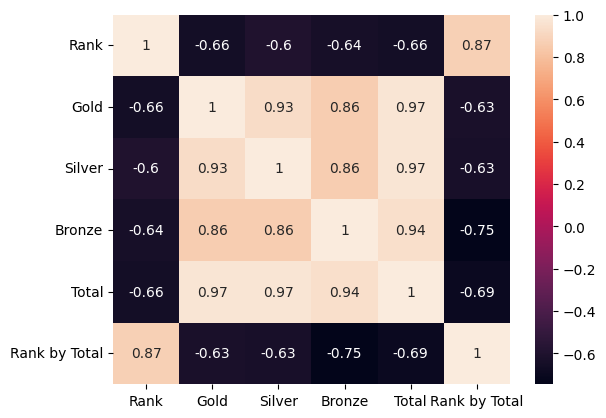

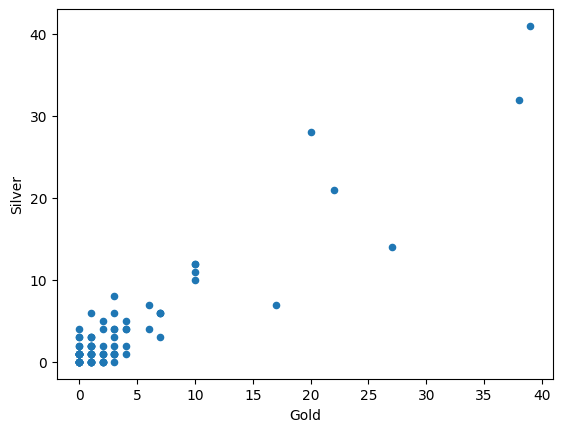

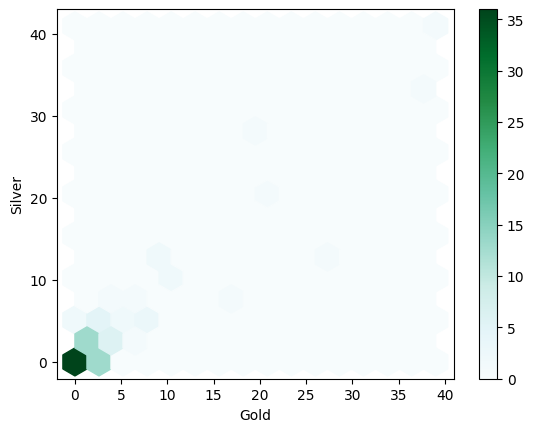

In [ ]:
# Correlation analysis and scatter comparisons
numeric_columns = medal_df.select_dtypes(include=np.number)
corr_matrix = numeric_columns.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix for Numeric Medal Metrics')
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=medal_df, x='Gold', y='Silver', ax=axs[0], color='blue')
sns.scatterplot(data=medal_df, x='Gold', y='Bronze', ax=axs[1], color='green')
axs[0].set_title('Gold vs Silver')
axs[1].set_title('Gold vs Bronze')
plt.tight_layout()
plt.show()

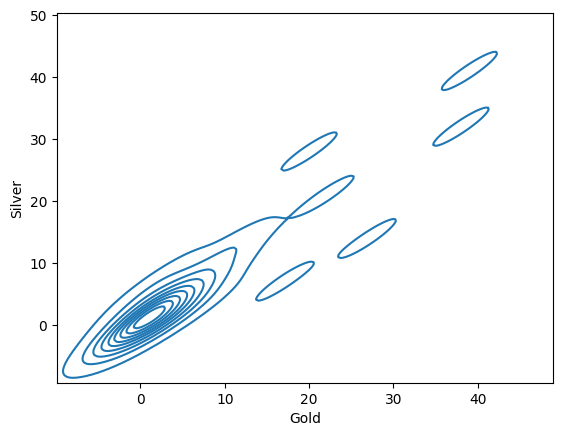

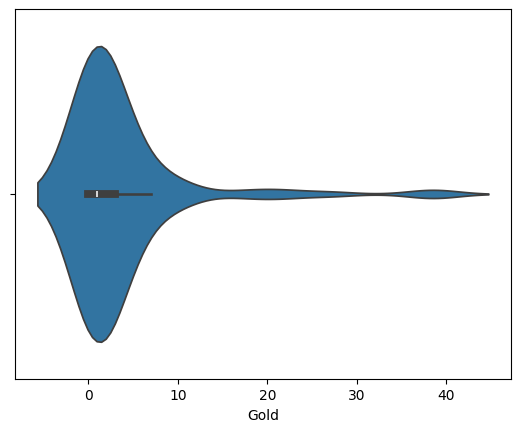

In [ ]:
# Density and violin plots for medal relationships
plt.figure(figsize=(8, 6))
sns.kdeplot(data=medal_df, x='Gold', y='Silver', fill=True, cmap='viridis', thresh=0.05)
plt.title('Joint Density of Gold and Silver Medals')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.violinplot(x=medal_df['Gold'], inner='quartile', color='orchid')
plt.title('Distribution of Gold Medals Across Countries')
plt.xlabel('Gold Medals')
plt.tight_layout()
plt.show()

In [ ]:
# Summary
# This notebook explores the Olympic medal dataset using summary statistics,
# distribution plots, correlation analysis, and medal ratio calculations.
# The derived columns show how gold, silver, and bronze medals contribute to each country's total.
